# LAB 2.1: XỬ LÝ ĐIỂM ẢNH & HISTOGRAM

**Mục tiêu:** Notebook này giúp bạn thực hành các phép biến đổi không gian tác động lên từng pixel độc lập (Point Operations) để tinh chỉnh độ sáng, tương phản. Đồng thời, bạn sẽ làm chủ kỹ thuật phân tích và cân bằng lược đồ xám (Histogram) từ cơ bản đến nâng cao (CLAHE).

## PHẦN 0: THIẾT LẬP MÔI TRƯỜNG (SETUP)

Giống như Chương 1, trước khi xử lý ảnh, chúng ta cần khai báo thư viện, kết nối dữ liệu và chuẩn bị hàm hiển thị ảnh hỗ trợ.

In [20]:
# 1. Import các thư viện cốt lõi
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Cấu hình kích thước ảnh hiển thị mặc định cho to rõ hơn
plt.rcParams['figure.figsize'] = [12, 6]
print("Đã import xong các thư viện: OpenCV, Numpy, Matplotlib.")

# 2. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# LƯU Ý: Chỉnh sửa đường dẫn bên dưới trỏ đúng vào thư mục chứa ảnh của bạn
path_dir = '/content/drive/MyDrive/ComputerVision-IT23M/ThucHanh_Chuong1/data/'

if os.path.exists(path_dir):
    print(f"Đường dẫn dữ liệu hợp lệ: {path_dir}")
else:
    print(f"Cảnh báo: Đường dẫn {path_dir} không tồn tại. Vui lòng kiểm tra lại.")

# 3. Hàm hỗ trợ hiển thị ảnh (Utility Function)
def show_img(img, title="Image"):
    """
    Hàm hiển thị ảnh dùng Matplotlib.
    Tự động chuyển BGR -> RGB nếu ảnh là ảnh màu load từ OpenCV.
    """
    plt.figure()
    if len(img.shape) == 3: # Ảnh màu
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else: # Ảnh xám hoặc nhị phân
        plt.imshow(img, cmap='gray')

    plt.title(title)
    plt.axis('off')
    plt.show()

Đã import xong các thư viện: OpenCV, Numpy, Matplotlib.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đường dẫn dữ liệu hợp lệ: /content/drive/MyDrive/ComputerVision-IT23M/ThucHanh_Chuong1/data/


## PHẦN 1: CÁC PHÉP BIẾN ĐỔI TUYẾN TÍNH (SÁNG & TƯƠNG PHẢN)

Thay vì dùng vòng lặp `for` lồng nhau cực kỳ chậm chạp để cộng/trừ từng pixel, chúng ta sẽ sử dụng hàm tối ưu của OpenCV để tính toán ma trận song song và xử lý luôn lỗi tràn giá trị (Clipping).

**Công thức tổng quát:**
$g(x,y)=\alpha \cdot f(x,y)+\beta$

* $\alpha$ (Alpha): Chỉnh tương phản (Độ lợi - Gain).
* $\beta$ (Beta): Chỉnh độ sáng (Độ lệch - Bias).

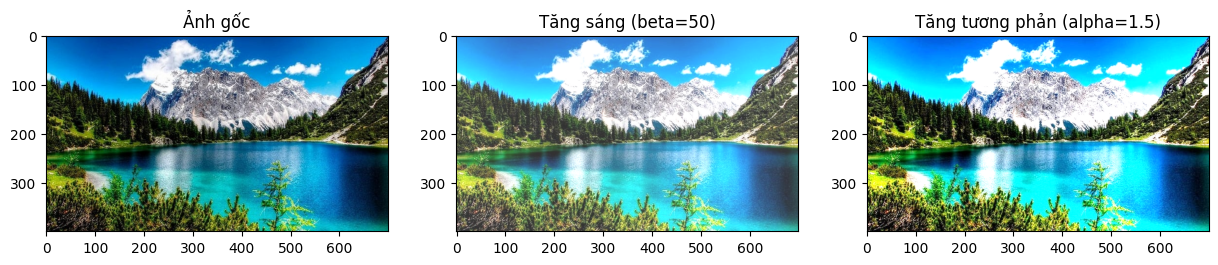

In [21]:
# Đọc một bức ảnh bất kỳ từ Drive
image_path = os.path.join(path_dir, 'image.jpg') # Thay tên file của bạn
img = cv2.imread(image_path)

if img is None:
    print("Không tìm thấy ảnh, hãy kiểm tra lại!")
else:
    # Định nghĩa hàm thay đổi sáng và tương phản dùng OpenCV
    def adjust_brightness_contrast(img, alpha=1.0, beta=0):
        # convertScaleAbs tự động nhân alpha, cộng beta và ép kiểu về uint8 (0-255)
        result = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        return result

    # Thử nghiệm 1: Tăng sáng (beta = 50), giữ nguyên tương phản (alpha = 1.0)
    img_brighter = adjust_brightness_contrast(img, alpha=1.0, beta=50)

    # Thử nghiệm 2: Tăng tương phản (alpha = 1.5), không tăng sáng (beta = 0)
    img_contrast = adjust_brightness_contrast(img, alpha=1.5, beta=0)

    # Hiển thị so sánh
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title("Ảnh gốc")
    plt.subplot(132), plt.imshow(cv2.cvtColor(img_brighter, cv2.COLOR_BGR2RGB)), plt.title("Tăng sáng (beta=50)")
    plt.subplot(133), plt.imshow(cv2.cvtColor(img_contrast, cv2.COLOR_BGR2RGB)), plt.title("Tăng tương phản (alpha=1.5)")
    plt.show()

## PHẦN 1.5: KÉO DÃN TƯƠNG PHẢN (CONTRAST STRETCHING) BẰNG TOÁN HỌC

Khi một bức ảnh bị mờ sương hoặc thiếu sáng, các giá trị pixel thường bị co cụm lại trong một dải hẹp (ví dụ: chỉ từ 50 đến 120).
Kéo dãn tương phản (Contrast Stretching) là kỹ thuật tìm giá trị nhỏ nhất ($Min$) và lớn nhất ($Max$) hiện có trong ảnh, sau đó dùng toán học "kéo dãn" chúng ra phủ kín toàn dải từ 0 đến 255.

**Công thức toán học:**


$$P_{new} = \frac{P_{old} - Min}{Max - Min} \times 255$$

Kỹ thuật này rất an toàn vì nó giữ nguyên hoàn toàn hình dáng biểu đồ gốc (chỉ kéo giãn ra) nên không gây ra nhiễu hạt nghiêm trọng như Histogram Equalization.

Dải màu gốc của ảnh: Min = 96, Max = 255


/tmp/ipykernel_143/4238968735.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_low_rgb.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_143/4238968735.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_stretched.ravel(), 256, [0, 256], color='gray')


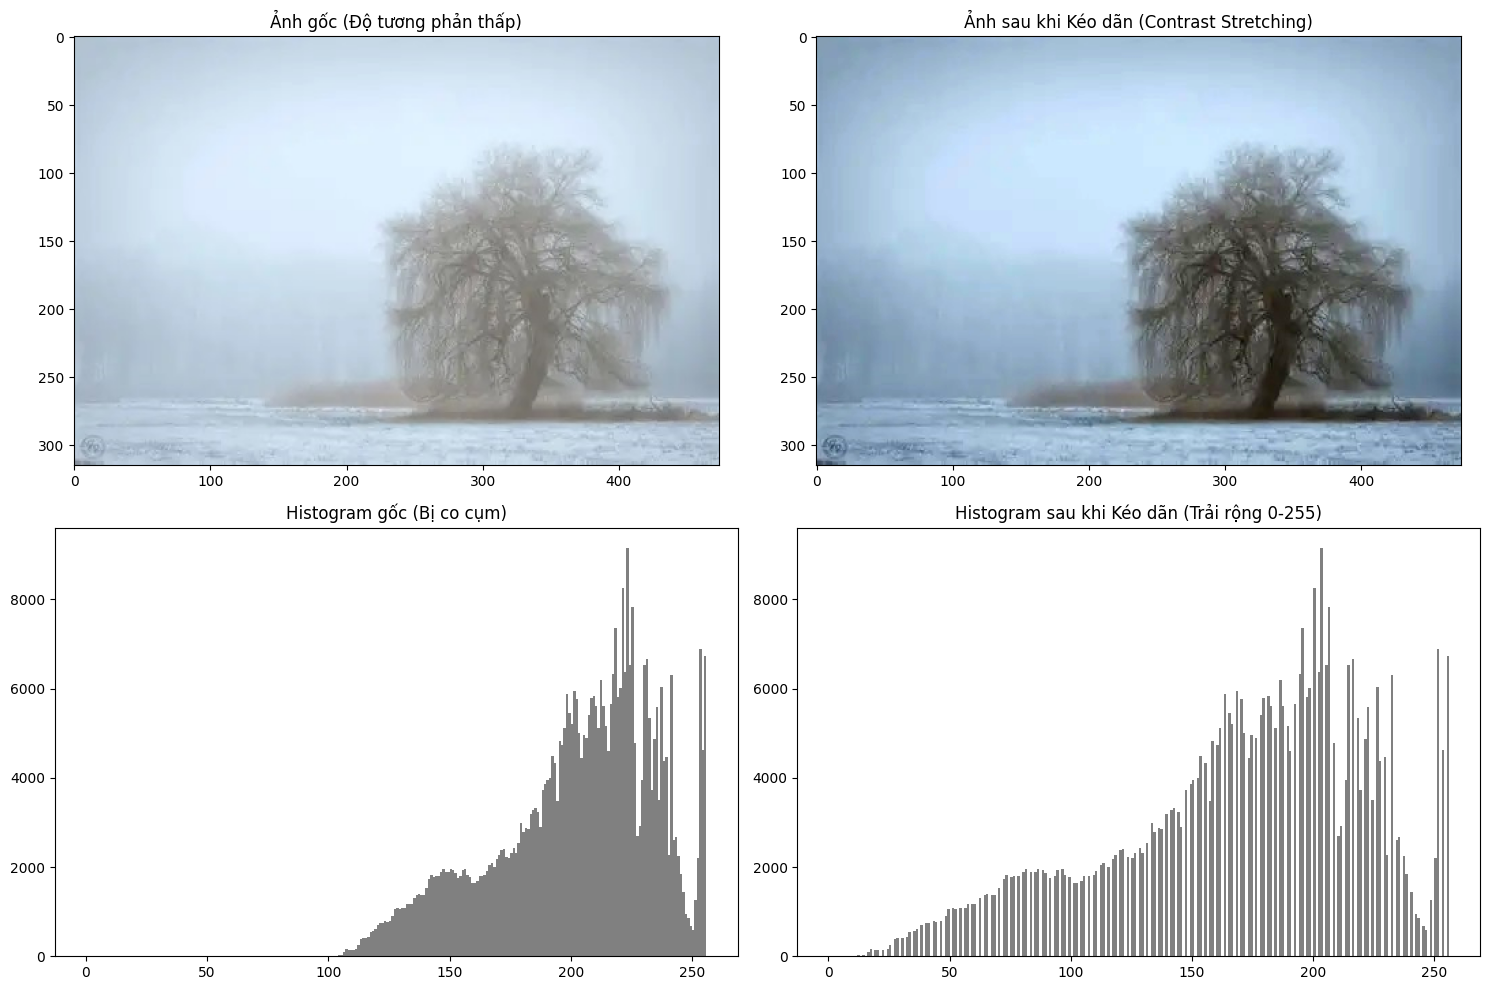

In [26]:
# 1. Đọc một bức ảnh có độ tương phản thấp (ví dụ ảnh chụp trời mù sương)
img_low_contrast = cv2.imread(os.path.join(path_dir, 'low_contrast.jpg'))

if img_low_contrast is not None:
    # Chuyển sang RGB để hiển thị và tính toán
    img_low_rgb = cv2.cvtColor(img_low_contrast, cv2.COLOR_BGR2RGB)

    # 2. Tìm giá trị Min và Max hiện tại của bức ảnh
    min_val = np.min(img_low_rgb)
    max_val = np.max(img_low_rgb)
    print(f"Dải màu gốc của ảnh: Min = {min_val}, Max = {max_val}")

    # 3. Áp dụng công thức Contrast Stretching bằng toán học ma trận Numpy
    # Chú ý: Cần ép kiểu sang float để tránh làm tròn sai khi chia
    img_stretched = (img_low_rgb - min_val) / (max_val - min_val) * 255.0

    # Ép kiểu ngược lại về uint8 (0-255) để có thể hiển thị như một bức ảnh chuẩn
    img_stretched = np.uint8(img_stretched)

    # 4. Trực quan hóa kết quả và so sánh
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    # Hàng 1: Hình ảnh
    axs[0, 0].imshow(img_low_rgb)
    axs[0, 0].set_title("Ảnh gốc (Độ tương phản thấp)")
    axs[0, 1].imshow(img_stretched)
    axs[0, 1].set_title("Ảnh sau khi Kéo dãn (Contrast Stretching)")

    # Hàng 2: Biểu đồ Histogram tương ứng (Dùng ravel() để duỗi phẳng ma trận 3D)
    axs[1, 0].hist(img_low_rgb.ravel(), 256, [0, 256], color='gray')
    axs[1, 0].set_title("Histogram gốc (Bị co cụm)")

    axs[1, 1].hist(img_stretched.ravel(), 256, [0, 256], color='gray')
    axs[1, 1].set_title("Histogram sau khi Kéo dãn (Trải rộng 0-255)")

    plt.tight_layout()
    plt.show()
else:
    print("Vui lòng tải lên file 'low_contrast.jpg' để chạy thử nghiệm này.")

## PHẦN 2: BIẾN ĐỔI PHI TUYẾN - GAMMA CORRECTION

Biến đổi tuyến tính tác động đều lên mọi điểm ảnh, dễ làm "cháy" vùng sáng khi cố nâng vùng tối. Phép biến đổi Gamma dùng đồ thị đường cong để "cứu" các bức ảnh thiếu sáng/ngược sáng một cách tự nhiên hơn.

**Công thức:** $g(x)=c\cdot f(x)^{\gamma}$

* Để chương trình chạy nhanh trên hàng triệu pixel, ta BẮT BUỘC phải dùng kỹ thuật **Look-Up Table (LUT)**. Ta tính sẵn kết quả của 256 giá trị pixel và lưu vào mảng, sau đó chỉ việc "tra bảng".


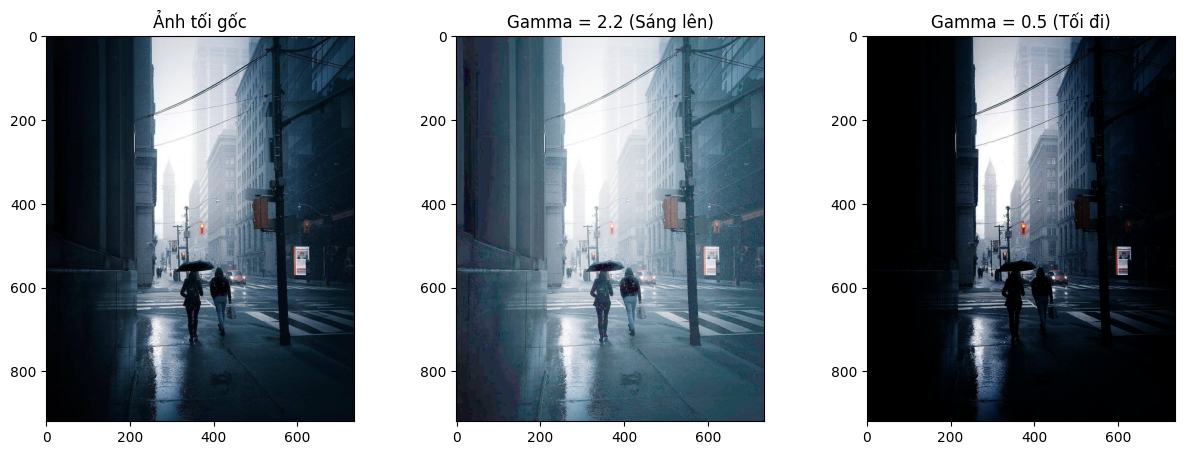

In [23]:
# Tải một ảnh bị thiếu sáng (underexposed)
dark_img_path = os.path.join(path_dir, 'night_underexposed.jpg')
img_dark = cv2.imread(dark_img_path)

if img_dark is not None:
    # Hàm Gamma Correction dùng LUT
    def gamma_correction(img, gamma=1.0):
        invGamma = 1.0 / gamma
        # Tạo bảng tra cứu (LUT) cho 256 giá trị pixel
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

        # Áp dụng bảng tra cứu vào ảnh bằng OpenCV
        return cv2.LUT(img, table)

    # Thử nghiệm với Gamma = 2.0 (Làm sáng ảnh) và Gamma = 0.5 (Làm tối ảnh)
    img_gamma_2 = gamma_correction(img_dark, gamma=2.2)
    img_gamma_05 = gamma_correction(img_dark, gamma=0.5)

    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(cv2.cvtColor(img_dark, cv2.COLOR_BGR2RGB)), plt.title("Ảnh tối gốc")
    plt.subplot(132), plt.imshow(cv2.cvtColor(img_gamma_2, cv2.COLOR_BGR2RGB)), plt.title("Gamma = 2.2 (Sáng lên)")
    plt.subplot(133), plt.imshow(cv2.cvtColor(img_gamma_05, cv2.COLOR_BGR2RGB)), plt.title("Gamma = 0.5 (Tối đi)")
    plt.show()

## PHẦN 2.5: TRỰC QUAN HÓA THỜI GIAN THỰC VỚI THANH TRƯỢT (INTERACTIVE WIDGETS)

Để thực sự hiểu rõ sự khác biệt giữa độ sáng ($\beta$), độ tương phản ($\alpha$) và Gamma ($\gamma$), không gì tốt hơn việc bạn tự tay kéo các thanh trượt và nhìn thấy bức ảnh thay đổi ngay lập tức.

Trong môi trường Jupyter Notebook / Google Colab, thay vì dùng `cv2.createTrackbar` (chỉ dành cho chạy trên máy tính cục bộ), chúng ta sẽ sử dụng thư viện `ipywidgets` để tạo ra các giao diện thanh trượt (Slider) vô cùng trực quan và hiện đại.

In [28]:
# Import thư viện tạo giao diện tương tác trong Notebook
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

# Đọc lại một bức ảnh bất kỳ để thử nghiệm
img_interactive = cv2.imread(os.path.join(path_dir, 'landscape.jpg'))

if img_interactive is not None:
    img_interactive_rgb = cv2.cvtColor(img_interactive, cv2.COLOR_BGR2RGB)

    # Hàm xử lý tổng hợp sẽ được gọi mỗi khi thanh trượt thay đổi
    def update_image(alpha, beta, gamma):
        # 1. Áp dụng Biến đổi tuyến tính (Alpha & Beta)
        linear_img = cv2.convertScaleAbs(img_interactive_rgb, alpha=alpha, beta=beta)

        # 2. Áp dụng Biến đổi phi tuyến (Gamma) lên kết quả vừa rồi
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        final_img = cv2.LUT(linear_img, table)

        # 3. Hiển thị kết quả
        plt.figure(figsize=(10, 6))
        plt.imshow(final_img)
        plt.title(f"Alpha (Tương phản): {alpha} | Beta (Sáng): {beta} | Gamma: {gamma}")
        plt.axis('off')
        plt.show()

    # Tạo giao diện tương tác bằng @interact
    print("KÉO CÁC THANH TRƯỢT BÊN DƯỚI ĐỂ XEM SỰ THAY ĐỔI:")
    interact(update_image,
             alpha=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description='Alpha:'),
             beta=IntSlider(value=0, min=-100, max=100, step=5, description='Beta:'),
             gamma=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Gamma:'))
else:
    print("Vui lòng tải lên file ảnh để chạy thử nghiệm này.")

KÉO CÁC THANH TRƯỢT BÊN DƯỚI ĐỂ XEM SỰ THAY ĐỔI:


interactive(children=(FloatSlider(value=1.0, description='Alpha:', max=3.0), IntSlider(value=0, description='B…

## PHẦN 3: SO SÁNH GLOBAL EQUALIZATION VÀ CLAHE

Histogram (Lược đồ xám) là công cụ bắt bệnh bức ảnh. Khi ảnh bị mờ nhạt, ta thường dùng thuật toán Cân bằng Histogram toàn cục (`cv2.equalizeHist`). Tuy nhiên, nó có nhược điểm là làm khuếch đại nhiễu ở những vùng trơn (như bầu trời).

**CLAHE** (Contrast Limited Adaptive Histogram Equalization) giải quyết bài toán này bằng cách chia nhỏ ảnh thành các lưới (grid) và giới hạn độ tương phản (Clip Limit).

/tmp/ipykernel_143/2627830588.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='black'); axs[1, 0].set_title("Histogram Gốc")
/tmp/ipykernel_143/2627830588.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_eq.ravel(), 256, [0, 256], color='black'); axs[1, 1].set_title("Histogram Global EQ")
/tmp/ipykernel_143/2627830588.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 2].hist(img_clahe.ravel(), 256, [0, 256], color='black'); axs[1, 2].set_title("Histogram CLAHE")


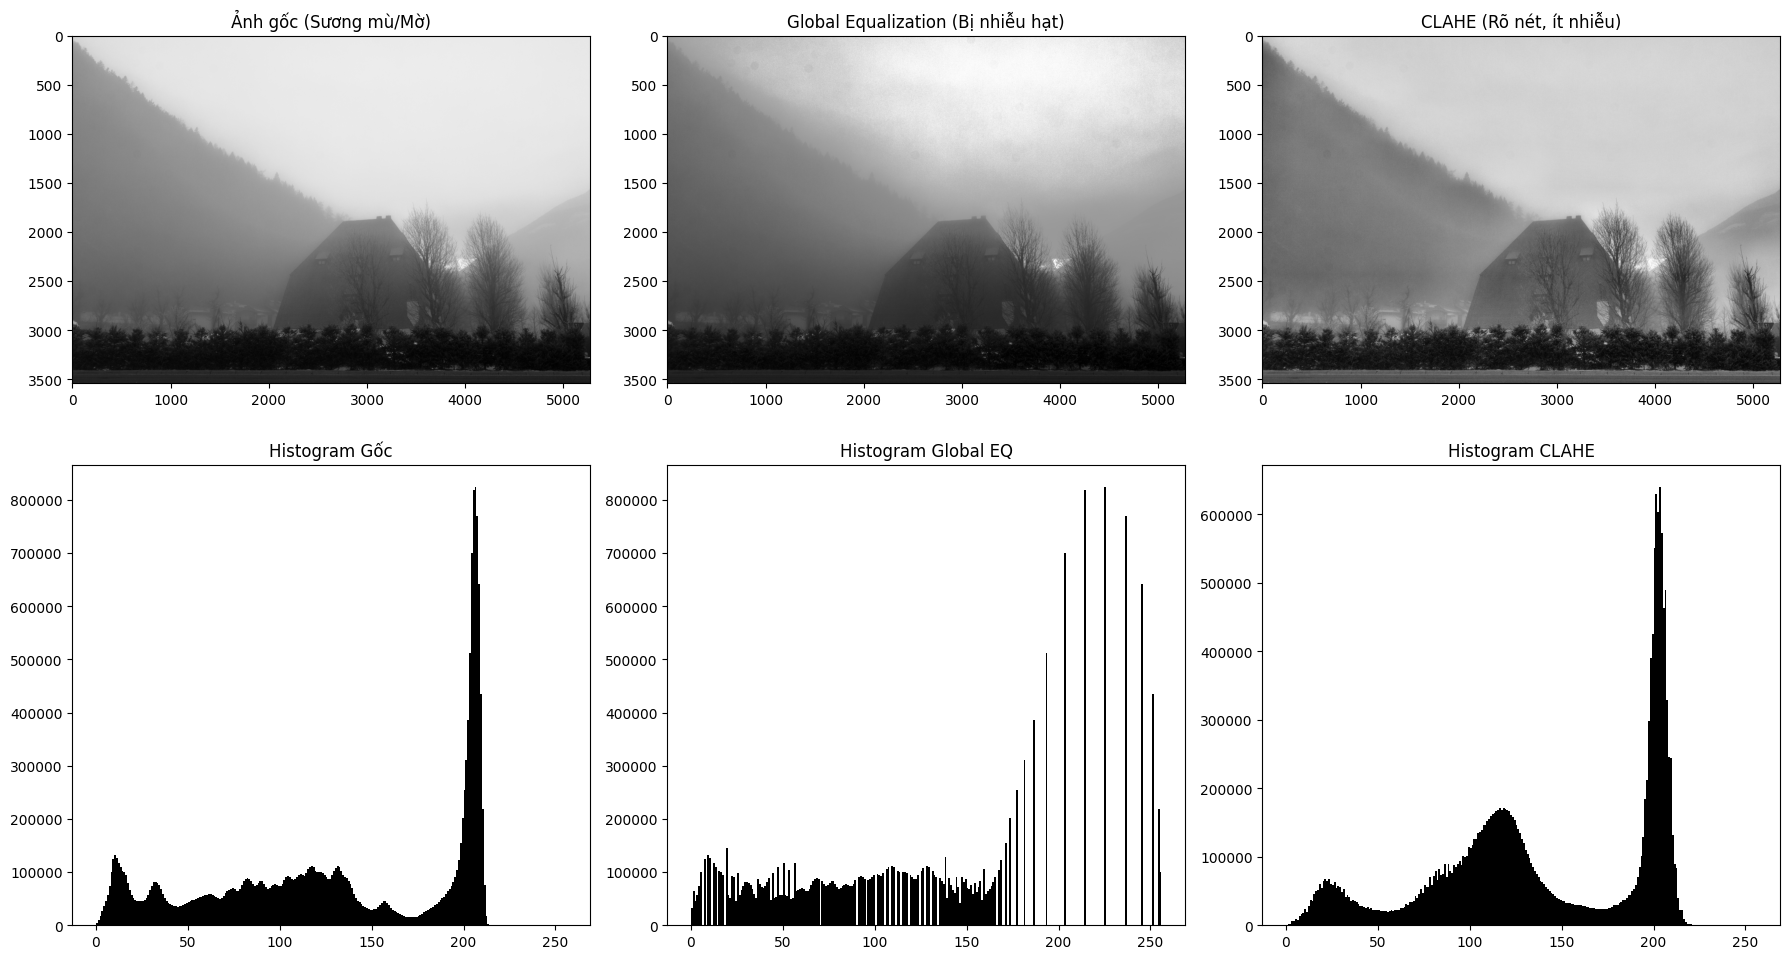

In [24]:
# Đọc ảnh và chuyển sang Grayscale để thực hiện cân bằng
img_gray = cv2.imread(os.path.join(path_dir, 'foggy_scene.jpg'), cv2.IMREAD_GRAYSCALE)

if img_gray is not None:
    # 1. Global Histogram Equalization
    img_eq = cv2.equalizeHist(img_gray)

    # 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_gray)

    # 3. Trực quan hóa Ảnh và Biểu đồ
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))

    # Hàng 1: Hiển thị ảnh
    axs[0, 0].imshow(img_gray, cmap='gray'); axs[0, 0].set_title("Ảnh gốc (Sương mù/Mờ)")
    axs[0, 1].imshow(img_eq, cmap='gray'); axs[0, 1].set_title("Global Equalization (Bị nhiễu hạt)")
    axs[0, 2].imshow(img_clahe, cmap='gray'); axs[0, 2].set_title("CLAHE (Rõ nét, ít nhiễu)")

    # Hàng 2: Hiển thị biểu đồ Histogram tương ứng
    axs[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='black'); axs[1, 0].set_title("Histogram Gốc")
    axs[1, 1].hist(img_eq.ravel(), 256, [0, 256], color='black'); axs[1, 1].set_title("Histogram Global EQ")
    axs[1, 2].hist(img_clahe.ravel(), 256, [0, 256], color='black'); axs[1, 2].set_title("Histogram CLAHE")

    plt.tight_layout()
    plt.show()

## PHẦN 3.1: PHÂN TÍCH HISTOGRAM TRÊN ẢNH MÀU (RGB HISTOGRAM)

Biểu đồ Histogram không chỉ dùng cho ảnh xám (Grayscale). Khi xử lý ảnh màu, việc vẽ chồng 3 biểu đồ của 3 kênh Đỏ (Red), Lục (Green), Lam (Blue) lên cùng một trục tọa độ sẽ giúp chúng ta dễ dàng "bắt bệnh" xem bức ảnh có bị ám màu (color cast) hay không.
*Ví dụ: Nếu đỉnh của biểu đồ kênh Red nằm tuốt về bên phải (gần 255) trong khi Blue và Green nằm ở giữa, bức ảnh chắc chắn đang bị ám đỏ gắt.*

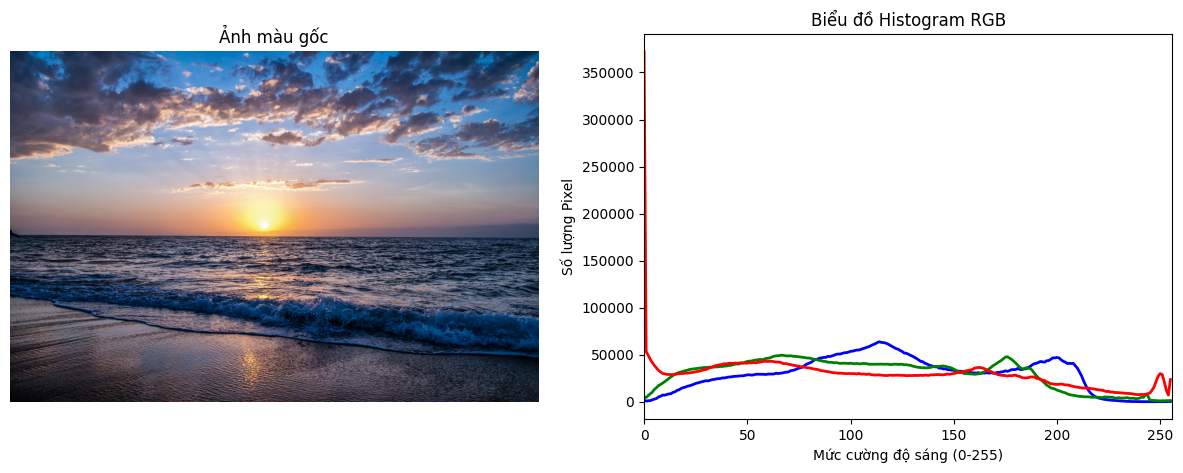

In [33]:
# Đọc một bức ảnh màu (ví dụ ảnh chụp hoàng hôn hoặc ảnh bị ám màu)
img_color = cv2.imread(os.path.join(path_dir, 'sunset.jpg'))

if img_color is not None:
    # Tách 3 kênh màu (OpenCV lưu theo thứ tự B, G, R)
    colors = ('b', 'g', 'r')

    plt.figure(figsize=(15, 5))

    # Hiển thị ảnh gốc
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title("Ảnh màu gốc")
    plt.axis('off')

    # Vẽ RGB Histogram
    plt.subplot(1, 2, 2)
    plt.title("Biểu đồ Histogram RGB")
    plt.xlabel("Mức cường độ sáng (0-255)")
    plt.ylabel("Số lượng Pixel")

    # Dùng vòng lặp để tính và vẽ histogram cho từng kênh màu
    for i, color in enumerate(colors):
        # cv2.calcHist(images, channels, mask, histSize, ranges)
        hist = cv2.calcHist([img_color], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, linewidth=2)
        plt.xlim([0, 256])

    plt.show()
else:
    print("Vui lòng tải lên file ảnh màu 'sunset.jpg'.")

## PHẦN 3.2: SO KHỚP HISTOGRAM (HISTOGRAM MATCHING)

Bạn có một bức ảnh chụp bị nhợt nhạt và muốn nó mang "tông màu" rực rỡ của một bức ảnh hoàng hôn khác? Thuật toán **So khớp Histogram** sẽ tính toán và biến đổi biểu đồ của ảnh gốc sao cho hình dáng của nó bám sát nhất với biểu đồ của ảnh mẫu (Reference Image). Kỹ thuật này dùng nhiều trong điện ảnh (color grading) và đồng bộ màu hệ thống camera.

Chúng ta sẽ sử dụng thư viện `scikit-image` (skimage) vì nó cung cấp hàm so khớp màu cực kỳ tối ưu.

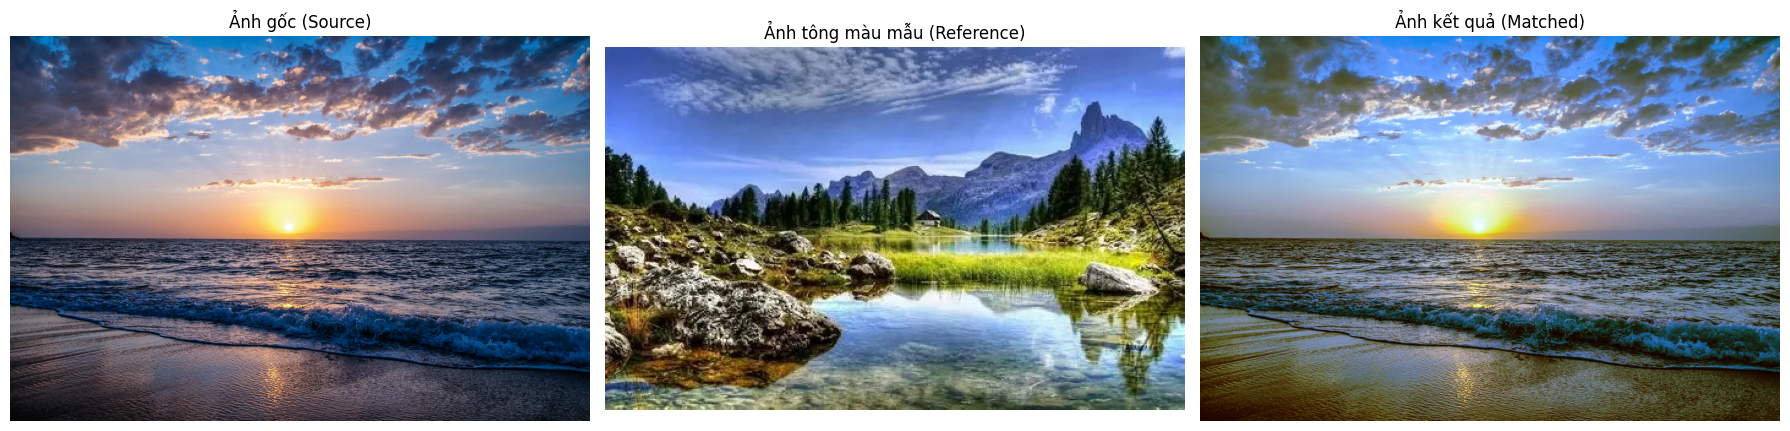

In [34]:
# Import hàm match_histograms từ scikit-image
from skimage.exposure import match_histograms

# Đọc ảnh gốc (Cần sửa màu) và ảnh mẫu (Tông màu đẹp)
img_source = cv2.imread(os.path.join(path_dir, 'sunset.jpg'))
img_reference = cv2.imread(os.path.join(path_dir, 'landscape.jpg'))

if img_source is not None and img_reference is not None:
    # Chuyển về RGB
    img_src_rgb = cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB)
    img_ref_rgb = cv2.cvtColor(img_reference, cv2.COLOR_BGR2RGB)

    # Thực hiện So khớp Histogram cho cả 3 kênh màu (multichannel=True)
    img_matched = match_histograms(img_src_rgb, img_ref_rgb, channel_axis=-1)

    # Hiển thị
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].imshow(img_src_rgb); axs[0].set_title("Ảnh gốc (Source)")
    axs[1].imshow(img_ref_rgb); axs[1].set_title("Ảnh tông màu mẫu (Reference)")
    axs[2].imshow(img_matched); axs[2].set_title("Ảnh kết quả (Matched)")

    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Vui lòng tải lên ảnh source và reference.")

## PHẦN 3.3: TÌM NGƯỠNG PHÂN ĐOẠN TỰ ĐỘNG (OTSU'S THRESHOLDING)

Nhìn vào biểu đồ Histogram, nếu bạn thấy nó có hình dáng giống 2 ngọn núi (Bimodal Histogram) - một ngọn đại diện cho nền tối, một ngọn đại diện cho đối tượng sáng. Làm sao để máy tính tự động tìm ra "thung lũng" giữa 2 ngọn núi đó để cắt ngưỡng (Threshold) phân tách đối tượng?
Thuật toán **Otsu** sẽ duyệt qua tất cả các giá trị từ 0-255 và dựa trên phương sai của Histogram để tự động tìm ra ngưỡng $T$ tối ưu nhất.

Ngưỡng T tối ưu mà thuật toán Otsu tự động tìm ra là: 148.0


/tmp/ipykernel_143/3298977183.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1].hist(img_otsu.ravel(), 256, [0, 256], color='gray')


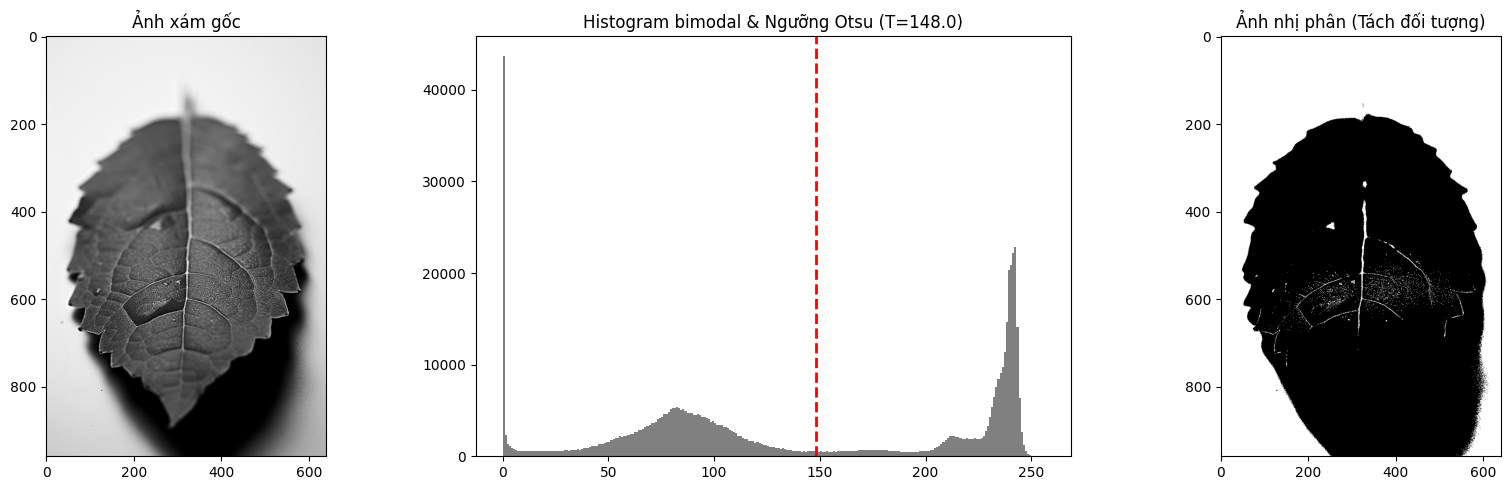

In [40]:
# Đọc ảnh văn bản hoặc vật thể rõ ràng trên nền (ví dụ: vân tay, lá cây)
img_otsu = cv2.imread(os.path.join(path_dir, 'leaf_on_background.jpg'), cv2.IMREAD_GRAYSCALE)

if img_otsu is not None:
    # 1. Áp dụng Phân ngưỡng Otsu (OpenCV tự tính ngưỡng T, bỏ qua giá trị 127 mình tự truyền)
    ret_T, img_binary = cv2.threshold(img_otsu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    print(f"Ngưỡng T tối ưu mà thuật toán Otsu tự động tìm ra là: {ret_T}")

    # 2. Hiển thị kết quả
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Ảnh gốc
    axs[0].imshow(img_otsu, cmap='gray'); axs[0].set_title("Ảnh xám gốc")

    # Biểu đồ Histogram với đường cắt T
    axs[1].hist(img_otsu.ravel(), 256, [0, 256], color='gray')
    axs[1].axvline(x=ret_T, color='red', linestyle='dashed', linewidth=2)
    axs[1].set_title(f"Histogram bimodal & Ngưỡng Otsu (T={ret_T})")

    # Ảnh nhị phân (Đã tách nền)
    axs[2].imshow(img_binary, cmap='gray'); axs[2].set_title("Ảnh nhị phân (Tách đối tượng)")

    plt.tight_layout()
    plt.show()

## PHẦN 5: HỆ THỐNG BÀI TẬP TỰ LUYỆN (HOMEWORK)

Dưới đây là 10 bài tập giúp các bạn ôn tập và vận dụng linh hoạt các kiến thức đã học trong Lab 2.1. Hãy tạo các Code Cell mới ngay bên dưới mỗi yêu cầu để thực hiện nhé.

**Bài 1: Truy tìm thông số Alpha và Beta tối ưu**

* **Yêu cầu:** Tải một bức ảnh chụp thiếu sáng nghiêm trọng. Sử dụng vòng lặp `for` lồng nhau (hoặc thanh trượt tương tác) để thử nghiệm các tổ hợp giá trị $\alpha$ (từ 1.0 đến 3.0) và $\beta$ (từ 0 đến 100). In ra tổ hợp $\alpha, \beta$ mà bạn cho là cho ra bức ảnh ưng ý nhất.
* **Hướng dẫn:** Có thể dùng lại hàm `update_image` kết hợp `ipywidgets` ở Phần 2.5 để dò tìm, sau đó fix cứng giá trị vào hàm `cv2.convertScaleAbs()`.

**Bài 2: Tạo ảnh âm bản (Image Negative) thủ công**

* **Yêu cầu:** Tạo hiệu ứng ảnh âm bản (như phim chụp X-quang) bằng công thức toán học $g(x) = 255 - f(x)$. Hãy code bằng thao tác ma trận của NumPy, KHÔNG sử dụng hàm `cv2.bitwise_not`.
* **Hướng dẫn:** Chuyển ảnh sang dạng mảng NumPy, chỉ cần viết `img_negative = 255 - img`. Nhớ kiểm tra kiểu dữ liệu có bị tràn hay không.

**Bài 3: Đóng gói hàm Contrast Stretching**

* **Yêu cầu:** Ở phần 1.5, bạn đã biết cách Kéo dãn tương phản. Hãy viết một hàm Python hoàn chỉnh `def custom_contrast_stretching(img):` nhận đầu vào là một ảnh RGB và trả về ảnh đã kéo dãn. Áp dụng hàm này lên 3 bức ảnh khác nhau.
* **Hướng dẫn:** Đưa đoạn code tính `min_val`, `max_val` và công thức `(img - min) / (max - min) * 255` vào trong hàm. Trả về mảng `np.uint8()`.

**Bài 4: So sánh thời gian thực thi (Performance Profiling)**

* **Yêu cầu:** Chứng minh sức mạnh của Look-Up Table (LUT). Cài đặt phép tính Gamma ($\gamma = 2.2$) bằng 2 cách: (1) Dùng 2 vòng lặp `for` duyệt qua từng pixel của ảnh $1000 \times 1000$; (2) Dùng `cv2.LUT()`. Đo thời gian chạy của 2 cách và rút ra kết luận.
* **Hướng dẫn:** Import thư viện `time`. Dùng `start_time = time.time()` trước và sau khối code để tính thời gian. Cách 1 sẽ tốn vài giây, cách 2 chỉ tốn vài mili-giây.

**Bài 5: Bắt bệnh ảnh bằng RGB Histogram**

* **Yêu cầu:** Tìm một bức ảnh bị "ám xanh" (blue cast - thường gặp khi chụp dưới ánh đèn neon). Vẽ RGB Histogram để chứng minh đỉnh của kênh Blue đang bị lệch về bên phải (vùng sáng).
* **Hướng dẫn:** Sử dụng lại đoạn code ở Phần 3.1. Phân tích sự chênh lệch vị trí các đỉnh của 3 đường Red, Green, Blue.

**Bài 6: Khử ám màu (Color Correction) bằng Histogram Equalization kênh màu**

* **Yêu cầu:** Xử lý bức ảnh bị ám màu ở Bài 5. Thay vì cân bằng sáng cả ảnh, hãy tách 3 kênh màu (B, G, R), áp dụng `cv2.equalizeHist()` HOẶC Contrast stretching lên ĐỘC LẬP từng kênh, sau đó gộp lại.
* **Hướng dẫn:** Dùng `b, g, r = cv2.split(img)`. Cân bằng từng biến `b, g, r`. Sau đó gộp lại bằng `img_corrected = cv2.merge((b, g, r))`.

**Bài 7: Kỹ xảo điện ảnh - Biến Ngày thành Đêm**

* **Yêu cầu:** Sử dụng thuật toán So khớp Histogram (Histogram Matching) ở Phần 3.2. Dùng một bức ảnh chụp phong cảnh ban ngày (Source) và một bức ảnh chụp phong cảnh ban đêm hoặc hoàng hôn cực ngầu (Reference). Ép tông màu đêm sang ảnh ban ngày.
* **Hướng dẫn:** Đảm bảo ảnh Source và Reference có cùng số kênh màu (RGB). Dùng `match_histograms` của thư viện `skimage`.

**Bài 8: Khám phá điểm chết của CLAHE**

* **Yêu cầu:** Mặc dù CLAHE rất tốt, nhưng nếu chỉnh thông số sai, ảnh sẽ bị hỏng. Hãy thử nghiệm hàm `cv2.createCLAHE` với `clipLimit` cực lớn (ví dụ: 40.0) và lưới cực nhỏ `tileGridSize=(2,2)`. Quan sát và giải thích hiện tượng xảy ra.
* **Hướng dẫn:** Khi `clipLimit` quá lớn, CLAHE sẽ hoạt động gần giống Global Equalization, làm khuếch đại hạt nhiễu và làm mất đi sự mượt mà cục bộ.

**Bài 9: Otsu Thresholding vs Manual Thresholding**

* **Yêu cầu:** Lấy một bức ảnh chứa đối tượng trên nền phức tạp. Vẽ Histogram. Hãy nhìn bằng mắt thường và tự đoán một giá trị Threshold $T$ để cắt bằng `cv2.threshold(img, T, 255, cv2.THRESH_BINARY)`. Sau đó, cho thuật toán Otsu tự chạy. So sánh 2 kết quả.
* **Hướng dẫn:** Nếu Histogram không có rõ hình dáng 2 đỉnh (bimodal), mắt người sẽ rất khó chọn ngưỡng $T$, lúc này Otsu sẽ chứng minh giá trị của nó.

**Bài 10: Xây dựng Pipeline Tổng hợp (Mini-Project Segment)**

* **Yêu cầu:** Bạn có một bức ảnh chụp văn bản nhưng bị đổ bóng (chỗ sáng chỗ tối). Nếu dùng Otsu ngay lập tức, vùng tối sẽ bị đen toàn bộ. Hãy thiết kế một Pipeline: Chuyển ảnh xám $\to$ Áp dụng CLAHE để đồng đều ánh sáng $\to$ Áp dụng Otsu để tách chữ.
* **Hướng dẫn:** Đây là bài tập thực chiến kết hợp Phần 3 và Phần 3.3. Áp dụng CLAHE trước sẽ "cứu" các vùng bóng râm, giúp Otsu cắt ngưỡng chính xác hơn trên toàn bộ bề mặt.